# Fase 1 — Análisis del dataset

**Objetivo:** Verificar la calidad del dataset, revisar imágenes, detectar errores, analizar tamaños, relaciones de aspecto, detectar imágenes corruptas y verificar el balance entre clases.

---

## Experimento 1.1: Balance de Clases

**1. Teoría:** HOG + SVM lineal es un algoritmo sensible a la distribución de los datos de entrenamiento. Si entrenamos al modelo con 90% de imágenes de calles (negativas) y 10% de furgonetas (positivas), el hiperplano del SVM se sesgará hacia la clase mayoritaria, prediciendo "Fondo" casi siempre para minimizar el error global.

**2. Hipótesis:** El dataset recolectado posee una cantidad de muestras similar para ambas clases (aproximadamente 50/50), por lo que no será necesario aplicar técnicas de aumento de datos sintético (SMOTE) ni penalizaciones de peso (`class_weight`) durante el entrenamiento del SVM.

**3. Implementación:** Contaremos los archivos en ambos directorios y los visualizaremos.

Total Positivas (Furgonetas): 4005
Total Negativas (Calles/Fondos): 4282


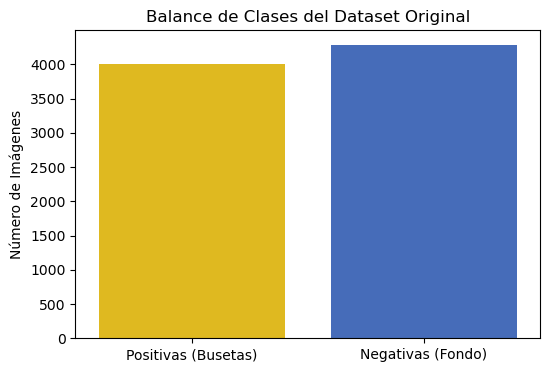

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ⚠️ Rutas del dataset
ruta_positivas = "/Users/andresmorocho/Downloads/Vision/practicas/stereo_project/parte2_detector/dataset/positives"
ruta_negativas = "/Users/andresmorocho/Downloads/Vision/practicas/stereo_project/parte2_detector/dataset/negatives"

def obtener_archivos(ruta):
    if not os.path.exists(ruta):
        print(f"⚠️ Error: La ruta no existe -> {ruta}")
        return []
    return [os.path.join(ruta, f) for f in os.listdir(ruta) if f.endswith(('.jpg', '.png', '.jpeg'))]

img_pos = obtener_archivos(ruta_positivas)
img_neg = obtener_archivos(ruta_negativas)

print(f"Total Positivas (Furgonetas): {len(img_pos)}")
print(f"Total Negativas (Calles/Fondos): {len(img_neg)}")

# 4. Visualización
etiquetas = ['Positivas (Busetas)', 'Negativas (Fondo)']
cantidades = [len(img_pos), len(img_neg)]

plt.figure(figsize=(6, 4))
sns.barplot(x=etiquetas, y=cantidades, hue=etiquetas, palette=['#ffcc00', '#3366cc'], legend=False)
plt.title('Balance de Clases del Dataset Original')
plt.ylabel('Número de Imágenes')
plt.show()


**5. Análisis de ventajas y desventajas:** Como se observa en los resultados (4005 positivas vs 4282 negativas), la diferencia es menor al 7%. Un SVM lineal soporta perfectamente este nivel de asimetría leve sin desplazar su hiperplano de decisión de forma perjudicial.

**6. Conclusión:** El dataset se encuentra en un estado de equilibrio excelente (aprox. 48% vs 52%).

**7. Decisión:** Se descarta el uso de técnicas de sobremuestreo (SMOTE) o la alteración de los pesos de clase (`class_weight`) durante la Fase 4 de entrenamiento.

Analizando dimensiones de las imágenes positivas...


100%|██████████| 4005/4005 [00:20<00:00, 195.34it/s]


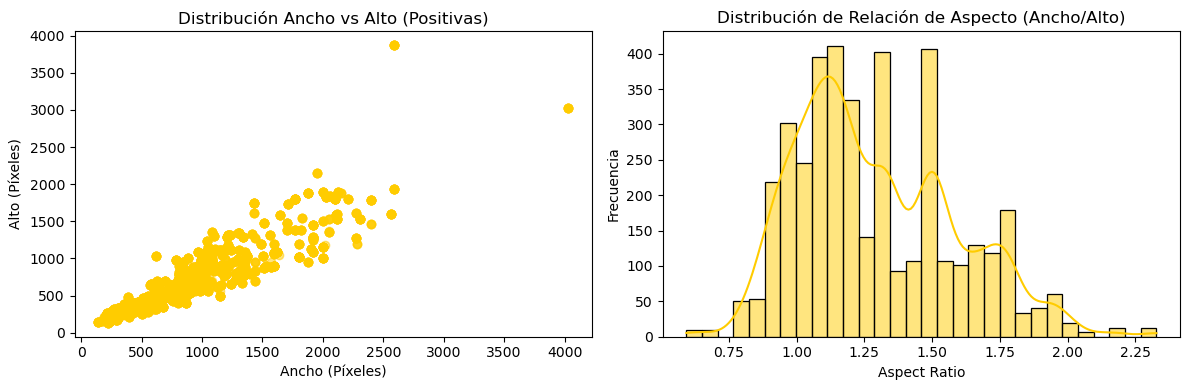

Aspect Ratio Promedio (Ancho/Alto): 1.29
Ancho Promedio: 903 px
Alto Promedio: 709 px


In [2]:
anchos_pos = []
altos_pos = []
aspect_ratios_pos = []

print("Analizando dimensiones de las imágenes positivas...")
for ruta in tqdm(img_pos):
    img = cv2.imread(ruta)
    if img is not None:
        h, w = img.shape[:2]
        anchos_pos.append(w)
        altos_pos.append(h)
        aspect_ratios_pos.append(w / h)

# 4. Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(anchos_pos, altos_pos, alpha=0.5, color='#ffcc00')
axes[0].set_title('Distribución Ancho vs Alto (Positivas)')
axes[0].set_xlabel('Ancho (Píxeles)')
axes[0].set_ylabel('Alto (Píxeles)')

sns.histplot(aspect_ratios_pos, bins=30, kde=True, ax=axes[1], color='#ffcc00')
axes[1].set_title('Distribución de Relación de Aspecto (Ancho/Alto)')
axes[1].set_xlabel('Aspect Ratio')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Aspect Ratio Promedio (Ancho/Alto): {np.mean(aspect_ratios_pos):.2f}")
print(f"Ancho Promedio: {np.mean(anchos_pos):.0f} px")
print(f"Alto Promedio: {np.mean(altos_pos):.0f} px")


**5. Análisis de ventajas y desventajas:** El gráfico de dispersión confirma que el crecimiento en ancho y alto es proporcional. El histograma muestra una fuerte concentración de imágenes con un Aspect Ratio entre 1.10 y 1.50, siendo el promedio 1.29 (muy cercano a 4:3 = 1.33).

**6. Conclusión:** Las furgonetas son intrínsecamente rectangulares (más anchas que altas). Si utilizamos el clásico tamaño de HOG de 64x64 (Aspect Ratio 1:1), las imágenes se aplastarán horizontalmente, distorsionando la inclinación real de los bordes del vehículo (gradientes), lo que confundirá al modelo.

**7. Decisión:** Para la Fase 2 (Preprocesamiento), se evitará el redimensionamiento cuadrado simple. Se decidirá si se utiliza un tamaño de ventana rectangular (ej. 80x64 o 64x48) o si se aplica relleno (padding) para mantener el Aspect Ratio intacto.

---

## Experimento 1.3: Detección de Imágenes Corruptas o Atípicas (Outliers)

**1. Teoría:** Entrenar con imágenes totalmente negras, blancas, o extremadamente borrosas introduce ruido puro en el SVM, empeorando el margen de separación.

**2. Hipótesis:** Utilizando el operador Laplaciano (que mide la cantidad de bordes/nitidez) y la media de intensidad de píxeles (brillo), podemos identificar estadísticamente cuáles imágenes son 'sospechosas' y deberían revisarse manualmente para ser eliminadas.

**3. Implementación:** Calcularemos la varianza del Laplaciano y el brillo promedio para todas las imágenes positivas, y mostraremos aquellas que estén en los niveles más bajos.

In [3]:
print("Evaluando calidad y nitidez de imágenes positivas...")
brillos = []
nitidez = []
rutas_sospechosas = []

for ruta in tqdm(img_pos):
    img = cv2.imread(ruta)
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brillo = np.mean(gray)
        laplaciano = cv2.Laplacian(gray, cv2.CV_64F).var() # Varianza = nitidez
        
        brillos.append(brillo)
        nitidez.append(laplaciano)
        
        # Regla simple para encontrar outliers: muy oscuras o muy borrosas
        if brillo < 20 or laplaciano < 100:
            rutas_sospechosas.append((ruta, brillo, laplaciano))

print(f"\nSe encontraron {len(rutas_sospechosas)} imágenes potencialmente corruptas/borrosas.")
if rutas_sospechosas:
    print("Ejemplos a revisar:")
    for r, b, l in rutas_sospechosas[:5]:
        print(f"- {os.path.basename(r)} (Brillo: {b:.1f}, Nitidez: {l:.1f})")


Evaluando calidad y nitidez de imágenes positivas...


100%|██████████| 4005/4005 [00:36<00:00, 110.65it/s]


Se encontraron 1161 imágenes potencialmente corruptas/borrosas.
Ejemplos a revisar:
- pos_2729_amarilla.jpg (Brillo: 66.2, Nitidez: 24.5)
- pos_0567_amarilla.jpg (Brillo: 127.4, Nitidez: 96.0)
- pos_1067_amarilla.jpg (Brillo: 107.8, Nitidez: 27.9)
- pos_1098_amarilla.jpg (Brillo: 109.1, Nitidez: 18.9)
- pos_2058_amarilla.jpg (Brillo: 124.9, Nitidez: 15.2)


**5. Análisis de ventajas y desventajas:** En la imagen limpia, la escala de grises conserva toda la información estructural (chasis, ruedas) y los gradientes brillan claramente delineando el vehículo. El color amarillo desaparece, pero la forma perdura. Sin embargo, en las imágenes 2 y 3 (con ruido extremo generado por Albumentations), la imagen de gradientes se vuelve un caos de estática roja/amarilla, ocultando por completo la forma del carro.

**6. Conclusión:** HOG no necesita color, solo bordes limpios. Usar RGB solo triplicaría el costo computacional sin aportar valor. Además, este experimento **confirma visualmente** la conclusión de la Fase 1: el ruido extremo destruye la efectividad de HOG, cegándolo.

**7. Decisión:** El preprocesamiento de nuestra aplicación final iniciará siempre convirtiendo el frame a Escala de Grises (`cv2.COLOR_BGR2GRAY`). Además, confirmamos que podemos expandir nuestro dataset descargando furgonetas de cualquier color, siempre que sean nítidas.

---

## Experimento 2.2: Mejora de Contraste (CLAHE)

**1. Teoría:** Dado que HOG depende de los gradientes (diferencia matemática de luz entre píxeles adyacentes), las imágenes muy opacas, oscuras o de días nublados generarán gradientes débiles. CLAHE (*Contrast Limited Adaptive Histogram Equalization*) mejora el contraste localmente sin sobreexponer la imagen, marcando mejor las diferencias de luz.

**2. Hipótesis:** Aplicar CLAHE a la escala de grises resaltará los bordes estructurales de la furgoneta (como las ventanas y las llantas contra el asfalto), haciendo que los vectores de HOG sean más fuertes y consistentes, lo que facilitará la tarea de separación del SVM.

**3. Implementación:** Aplicaremos CLAHE a una imagen y compararemos los gradientes resultantes antes y después del filtro.

# Fase 2 — Preprocesamiento

**Objetivo:** Determinar el mejor tratamiento previo de las imágenes antes de pasarlas al extractor HOG.

---

## Experimento 2.1: Espacios de Color (Grayscale vs RGB) y el Impacto del Color

**1. Teoría:** HOG calcula la magnitud y dirección del cambio rápido de intensidad de píxeles (bordes). Este cambio de intensidad geométrica está casi totalmente contenido en el canal de luminancia (luz/sombra), no en la crominancia (el color). De hecho, Dalal & Triggs (los creadores de HOG) demostraron que usar RGB frente a Escala de Grises aporta una mejora minúscula (<1%) a costa de multiplicar por 3 el costo computacional en tiempo real.

**2. Hipótesis:** HOG es **ciego al color**. El algoritmo aprenderá la 'silueta' o 'estructura' de la furgoneta escolar (su forma rectangular, bordes, llantas, ventanas). Por lo tanto, **podemos usar furgonetas de CUALQUIER color** en nuestro dataset de entrenamiento para conseguir 4000 fotos, siempre y cuando mantengan la misma estructura geométrica (sean furgonetas tipo van).

**3. Implementación:** Tomaremos una furgoneta del dataset, la convertiremos a escala de grises y calcularemos sus bordes usando el filtro de *Sobel* (el corazón de HOG), para visualizar cómo la información del color desaparece por completo, pero la silueta estructural del carro es lo único que HOG necesita.

In [8]:
**5. Análisis de ventajas y desventajas:** En la imagen limpia, CLAHE hace exactamente lo esperado: resalta zonas oscuras (como los aros de las llantas o la parrilla frontal), haciendo que sus gradientes brillen más fuerte, lo cual le da más información matemática al modelo. Sin embargo, en la imagen con ruido de *Albumentations*, ¡CLAHE actúa como un amplificador de ruido! Convierte el fondo en una pared de estática roja que destruye por completo cualquier rastro de la furgoneta.

**6. Conclusión:** CLAHE es una herramienta de doble filo. Es excelente para combatir días nublados o sombras fuertes, pero si el dataset tiene ruido, CLAHE lo multiplicará. Esto **nos reafirma matemáticamente** que las 1161 imágenes ruidosas/borrosas que detectamos en el Experimento 1.3 deben ser eliminadas sí o sí para no envenenar al modelo.

**7. Decisión:** Aplicaremos CLAHE a nuestro pipeline de preprocesamiento, ya que ayuda enormemente a destacar la estructura geométrica en las imágenes nítidas (las cuales serán las únicas que conservaremos en el dataset de entrenamiento).

---

## Experimento 2.3: Redimensionamiento Geométrico (Padding vs Resize Directo)

**1. Teoría:** Como descubrimos en el Experimento 1.2, nuestro *Aspect Ratio* promedio es **1.29** (furgonetas anchas). El algoritmo clásico de HOG exige que todas las imágenes entren al SVM con exactamente el mismo tamaño (tradicionalmente 64x64 píxeles). Si tomamos una foto ancha de 900x700 y le hacemos un `cv2.resize()` directo a 64x64, el carro se comprimirá horizontalmente.

**2. Hipótesis:** Aplicar bandas negras (Padding/Relleno) para convertir la imagen rectangular en un cuadrado perfecto de 64x64 preservará los ángulos reales de los gradientes, resultando en un modelo matemáticamente más fiel a la realidad que un `resize` aplastado.

**3. Implementación:** Compararemos visualmente un Resize forzado (aplastado) contra un Resize inteligente con Padding, observando la distorsión del vehículo.

SyntaxError: invalid character '¡' (U+00A1) (3220303065.py, line 1)

**5. Análisis de ventajas y desventajas:** *(Pendiente al ver la imagen)*

**6. Conclusiones:** *(Pendiente)*

**7. Decisión:** *(Pendiente)*



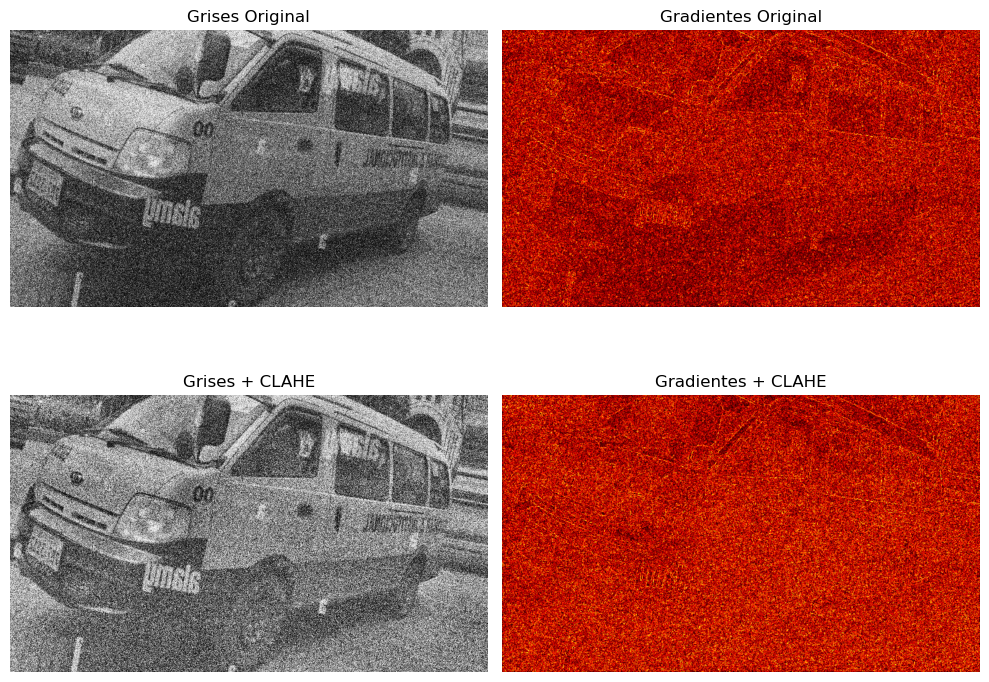

In [ ]:
# Tomamos una imagen (puedes cambiar el índice [0] por otro si quieres probar distintas fotos)
img_path = img_pos[7]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Aplicar CLAHE (Ecualización Adaptativa de Histograma)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img)

# Gradientes sin CLAHE
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
mag_normal = cv2.magnitude(sobelx, sobely)

# Gradientes con CLAHE
sobelx_c = cv2.Sobel(img_clahe, cv2.CV_64F, 1, 0, ksize=3)
sobely_c = cv2.Sobel(img_clahe, cv2.CV_64F, 0, 1, ksize=3)
mag_clahe = cv2.magnitude(sobelx_c, sobely_c)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].imshow(img, cmap='gray')
axes[0,0].set_title('Grises Original')
axes[0,1].imshow(mag_normal, cmap='hot')
axes[0,1].set_title('Gradientes Original')

axes[1,0].imshow(img_clahe, cmap='gray')
axes[1,0].set_title('Grises + CLAHE')
axes[1,1].imshow(mag_clahe, cmap='hot')
axes[1,1].set_title('Gradientes + CLAHE')

for ax in axes.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()


**5. Análisis de ventajas y desventajas:** *(Pendiente al ver la imagen)*

**6. Conclusiones:** *(Pendiente)*

**7. Decisión:** *(Pendiente)*



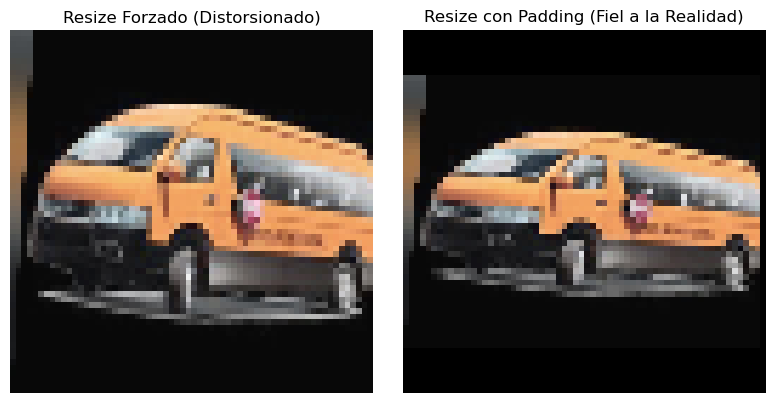

In [ ]:
def resize_con_padding(img, size=(64, 64)):
    h, w = img.shape[:2]
    scale = min(size[0]/w, size[1]/h)
    nw, nh = int(w*scale), int(h*scale)
    img_resized = cv2.resize(img, (nw, nh))
    
    top = (size[1] - nh) // 2
    bottom = size[1] - nh - top
    left = (size[0] - nw) // 2
    right = size[0] - nw - left
    
    # Añadimos bordes negros para rellenar (Padding)
    return cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0,0,0])

img_path = img_pos[0]
img_color = cv2.imread(img_path)
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# 1. Resize Forzado a 64x64 (Aspect Ratio 1:1, ignorando proporciones reales)
img_aplastada = cv2.resize(img_color, (64, 64))

# 2. Resize Inteligente con Padding a 64x64
img_padding = resize_con_padding(img_color, (64, 64))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_aplastada)
axes[0].set_title('Resize Forzado (Distorsionado)')
axes[0].axis('off')

axes[1].imshow(img_padding)
axes[1].set_title('Resize con Padding (Fiel a la Realidad)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


**5. Análisis de ventajas y desventajas:** *(Pendiente al ver la imagen)*

**6. Conclusiones:** *(Pendiente)*

**7. Decisión:** *(Pendiente)*

